In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score, confusion_matrix

In [4]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
data = pd.read_excel('Dry_Bean_Dataset\Dry_Bean_Dataset.xlsx')
data.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [6]:
data.drop_duplicates(inplace=True)

In [7]:
data.info()

<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  str    
dtypes: float64(14), int64(2), st

In [8]:
data.describe

<bound method NDFrame.describe of         Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0      28395    610.291       208.178117       173.888747      1.197191   
1      28734    638.018       200.524796       182.734419      1.097356   
2      29380    624.110       212.826130       175.931143      1.209713   
3      30008    645.884       210.557999       182.516516      1.153638   
4      30140    620.134       201.847882       190.279279      1.060798   
...      ...        ...              ...              ...           ...   
13606  42097    759.696       288.721612       185.944705      1.552728   
13607  42101    757.499       281.576392       190.713136      1.476439   
13608  42139    759.321       281.539928       191.187979      1.472582   
13609  42147    763.779       283.382636       190.275731      1.489326   
13610  42159    772.237       295.142741       182.204716      1.619841   

       Eccentricity  ConvexArea  EquivDiameter    Extent  Solidit

In [9]:
data.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [10]:
df = pd.DataFrame(data)

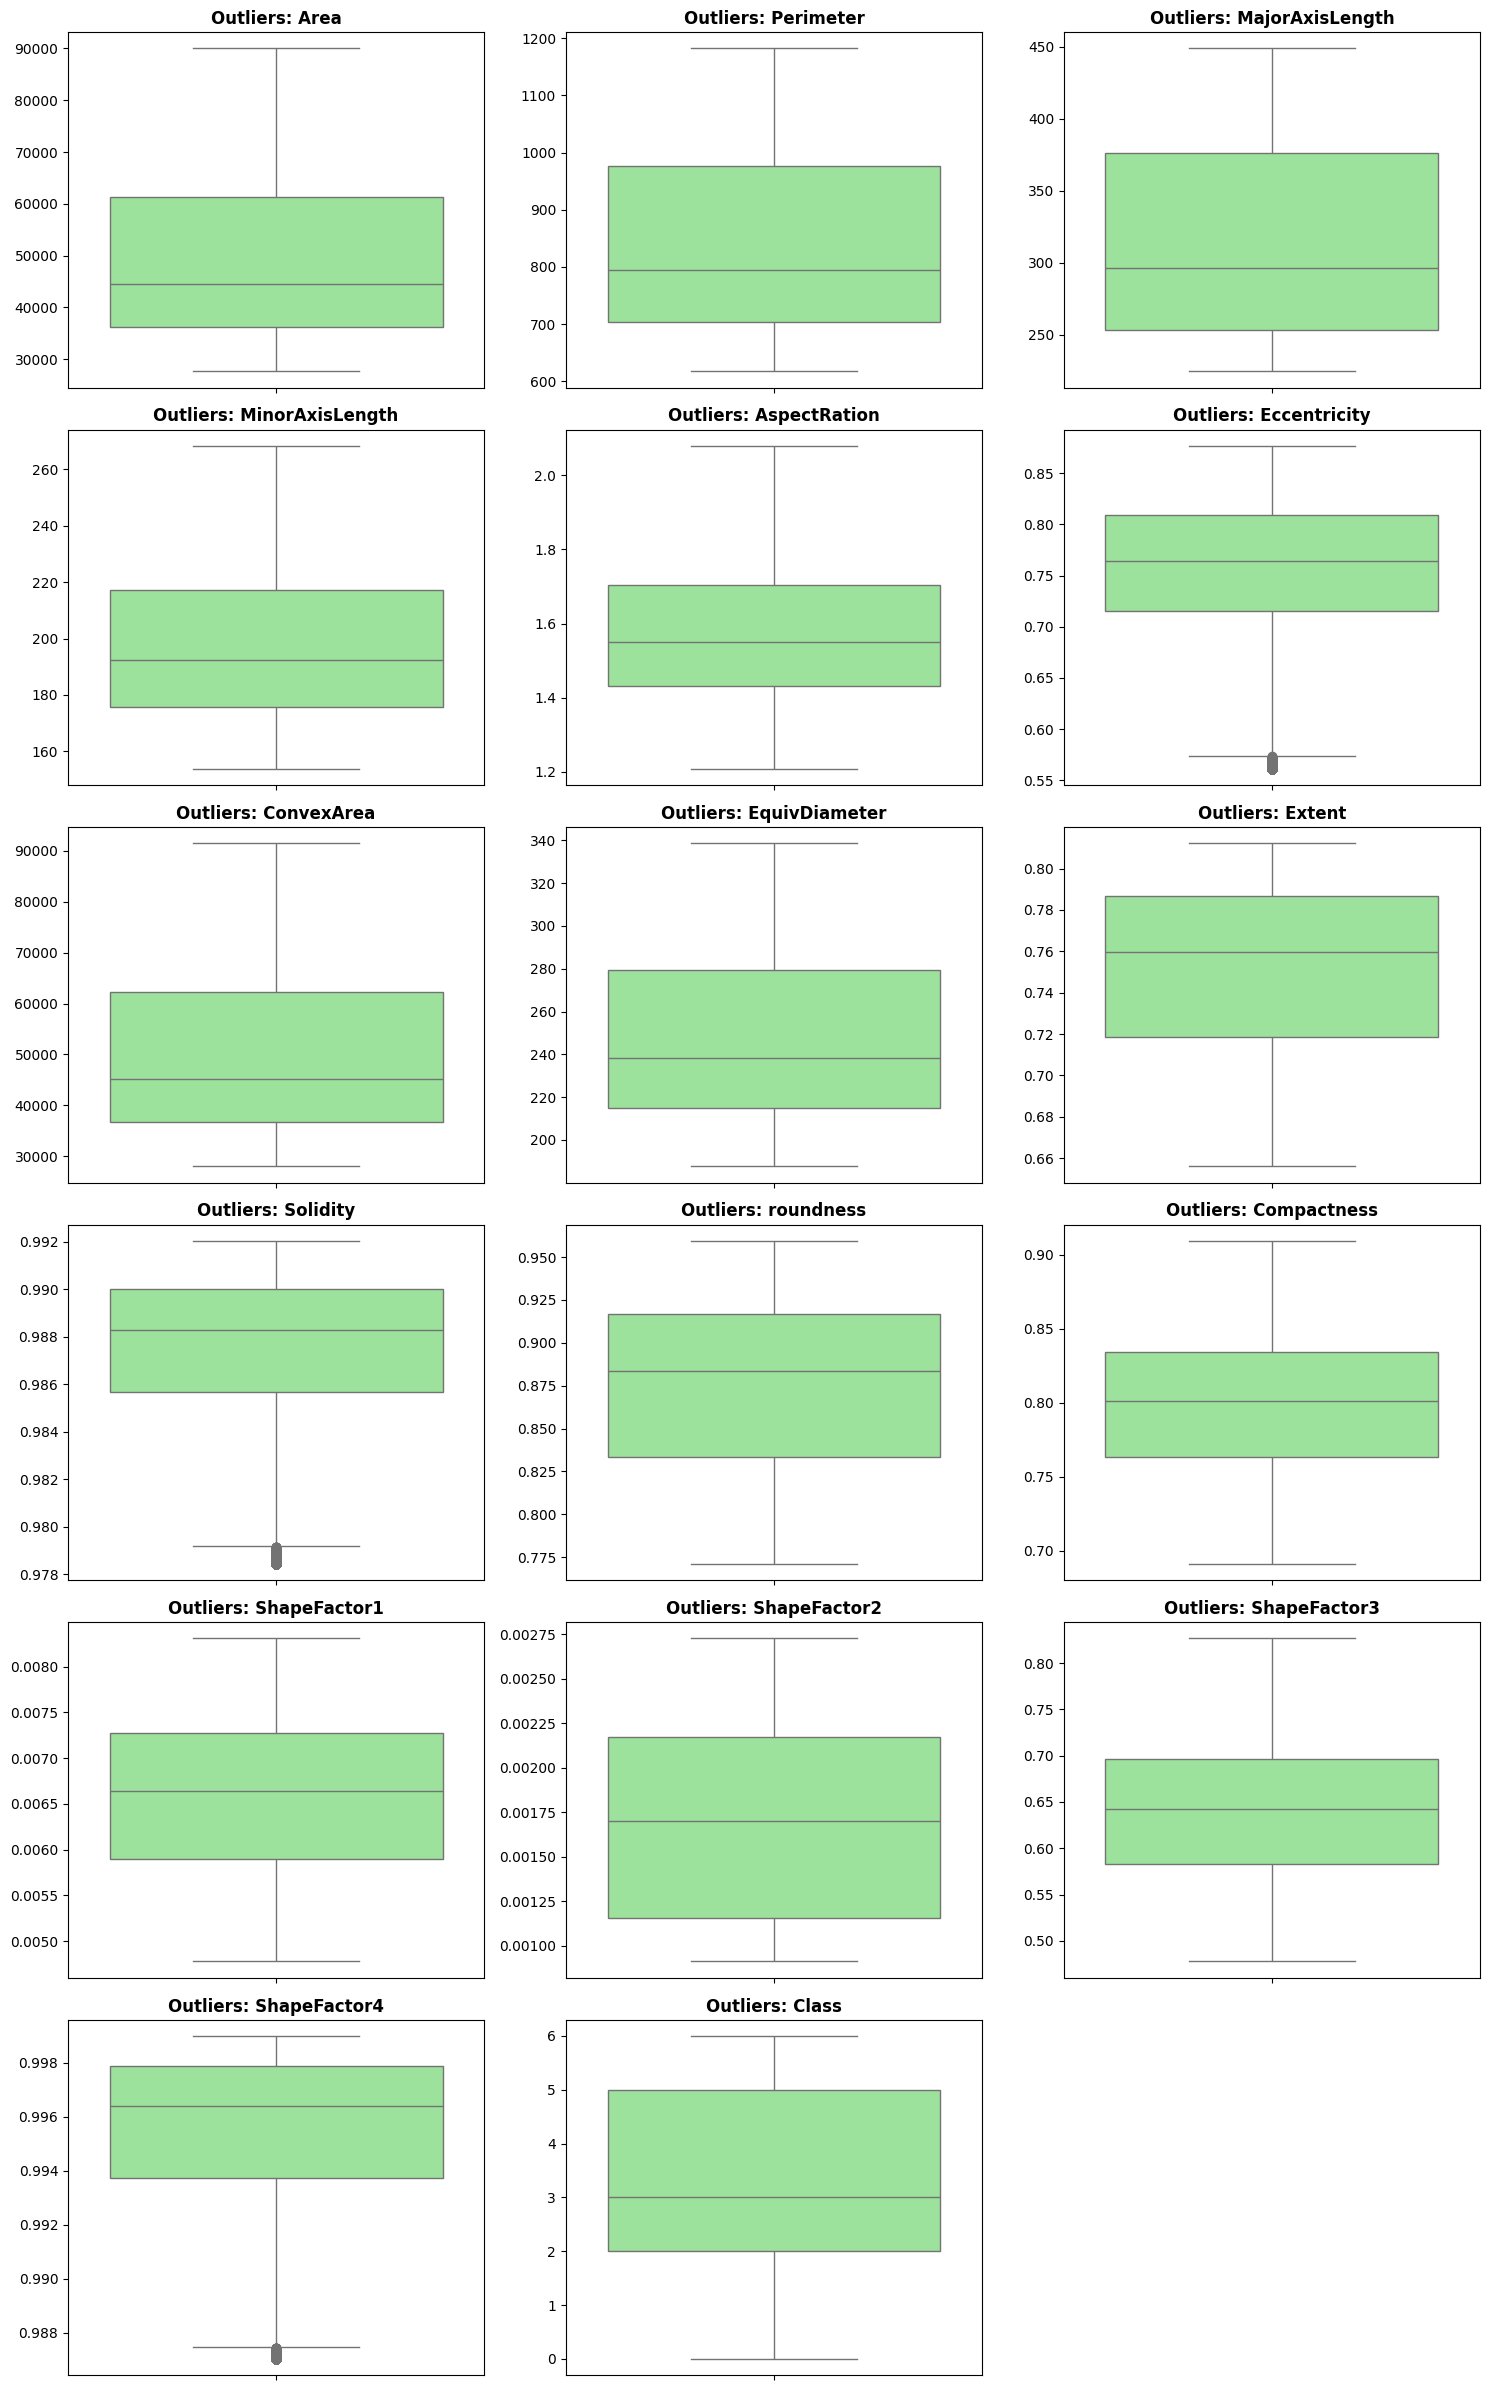

In [24]:
import pandas as pd
import math

numeric_features = df.select_dtypes(include=['number']).columns
categorical_features = df.select_dtypes(include=['object']).columns

jumlah_fitur = len(numeric_features)

# 2. Atur tata letak grid (misal: 3 kolom per baris)
kolom_grid = 3
baris_grid = math.ceil(jumlah_fitur / kolom_grid)

# 3. Buat kanvas (figure) dan kotak-kotaknya (axes)
# figsize diatur dinamis: lebar 15, tinggi menyesuaikan jumlah baris
fig, axes = plt.subplots(baris_grid, kolom_grid, figsize=(15, 4 * baris_grid))
axes = axes.flatten() # Ratakan array kotak agar mudah diisi pakai loop

# 4. Looping untuk menggambar boxplot Seaborn ke dalam masing-masing kotak
for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Sembunyikan label Y agar UI lebih bersih

# 5. Hapus kotak sisa yang kosong (jika total fitur Anda bukan kelipatan 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Rapikan jarak antar kotak dan tampilkan
plt.tight_layout()
plt.show()

In [20]:
df['Class'].unique()

<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

In [22]:
# Encoding Target

label_encoder = LabelEncoder()
categorical_features = ["Class"]

for col in categorical_features:
    df[col] = label_encoder.fit_transform(df[col])
    

df['Class'].unique()

array([5, 0, 1, 2, 4, 6, 3])

## Handle Outliers

In [ ]:

def cap_outliers_efficient(df, columns):
    df_capped = df.copy() # Membuat salinan agar data asli tidak rusak
    
    for col in columns:
        # Menentukan batas bawah (persentil 5%) dan atas (persentil 95%)
        lower_bound = df_capped[col].quantile(0.05)
        upper_bound = df_capped[col].quantile(0.95)
        
        # Fungsi clip() akan otomatis membatasi nilai yang kelebihan/kekurangan
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

# Penggunaan:
df = cap_outliers_efficient(df, numeric_features)

In [65]:
# Melihat CLass Imbalance

all_target = df["Class"].value_counts()


for nama_kelas, target in all_target.items():
    hasil = 0
    hasil = (target/all_target.sum()) * 100
    print(f"{nama_kelas} : {target}, persentase {hasil: .2f} %")

3 : 3546, persentase  26.18 %
6 : 2636, persentase  19.46 %
5 : 2027, persentase  14.97 %
4 : 1860, persentase  13.73 %
2 : 1630, persentase  12.04 %
0 : 1322, persentase  9.76 %
1 : 522, persentase  3.85 %


In [58]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,49868.859470,840.192783,314.587055,198.479251,1.579177,0.752484,50554.385587,248.245957,0.751085,0.987392,0.874865,0.800139,0.006597,0.001714,0.643636,0.995337,3.530311
std,17765.241479,167.226575,69.603920,31.202278,0.231948,0.083942,18109.510585,43.232935,0.043995,0.003623,0.054694,0.058437,0.000971,0.000568,0.093588,0.003330,1.832994
min,27645.200000,617.409100,224.604232,153.763175,1.207922,0.560923,28003.200000,187.613864,0.655897,0.978436,0.771017,0.691168,0.004777,0.000912,0.477714,0.987027,0.000000
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720,2.000000
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393,3.000000
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891,5.000000
max,89986.900000,1181.826900,448.636539,268.257569,2.078701,0.876682,91430.300000,338.489113,0.812179,0.992029,0.959403,0.909193,0.008307,0.002727,0.826631,0.998993,6.000000


In [76]:
# Split Dataset

scaler = StandardScaler()
X = df.drop(columns = 'Class')
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, stratify=y)

# Normalisasi FItur

numeric_column = X_train.select_dtypes(include = ['int64', 'float64']).columns
X_train[numeric_column] = scaler.fit_transform(X_train[numeric_column])
X_test[numeric_column] = scaler.transform(X_test[numeric_column]) 

In [61]:
print(numeric_column)

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


In [71]:
# Model LOAD

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)


In [77]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # tn, fp, fn, tp dihapus karena tidak bisa diterapkan langsung pada multi-class
    
    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        # Tambahkan average='weighted' untuk menangani multi-class yang imbalanced
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    return results

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}

# Buat DataFrame untuk meringkas hasil (looping Anda sebelumnya sudah sangat bagus!)
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })

# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)

# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)  0.933924   0.934268  0.933924  0.933998
1            Decision Tree (DT)  0.954965   0.957028  0.954965  0.953822
2            Random Forest (RF)  0.961240   0.963911  0.961240  0.958255
3  Support Vector Machine (SVM)  0.924326   0.924942  0.924326  0.924476
4              Naive Bayes (NB)  0.851606   0.826225  0.851606  0.837038


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
